In [82]:
import pandas as pd 
import optuna
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [3]:
df = pd.read_csv('../data/Bank_Churn.csv')

In [4]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# usunięcie zbędnych kolumn do modelowania 

df = df.drop(columns= ['CustomerId', 'Surname'])

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [25]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

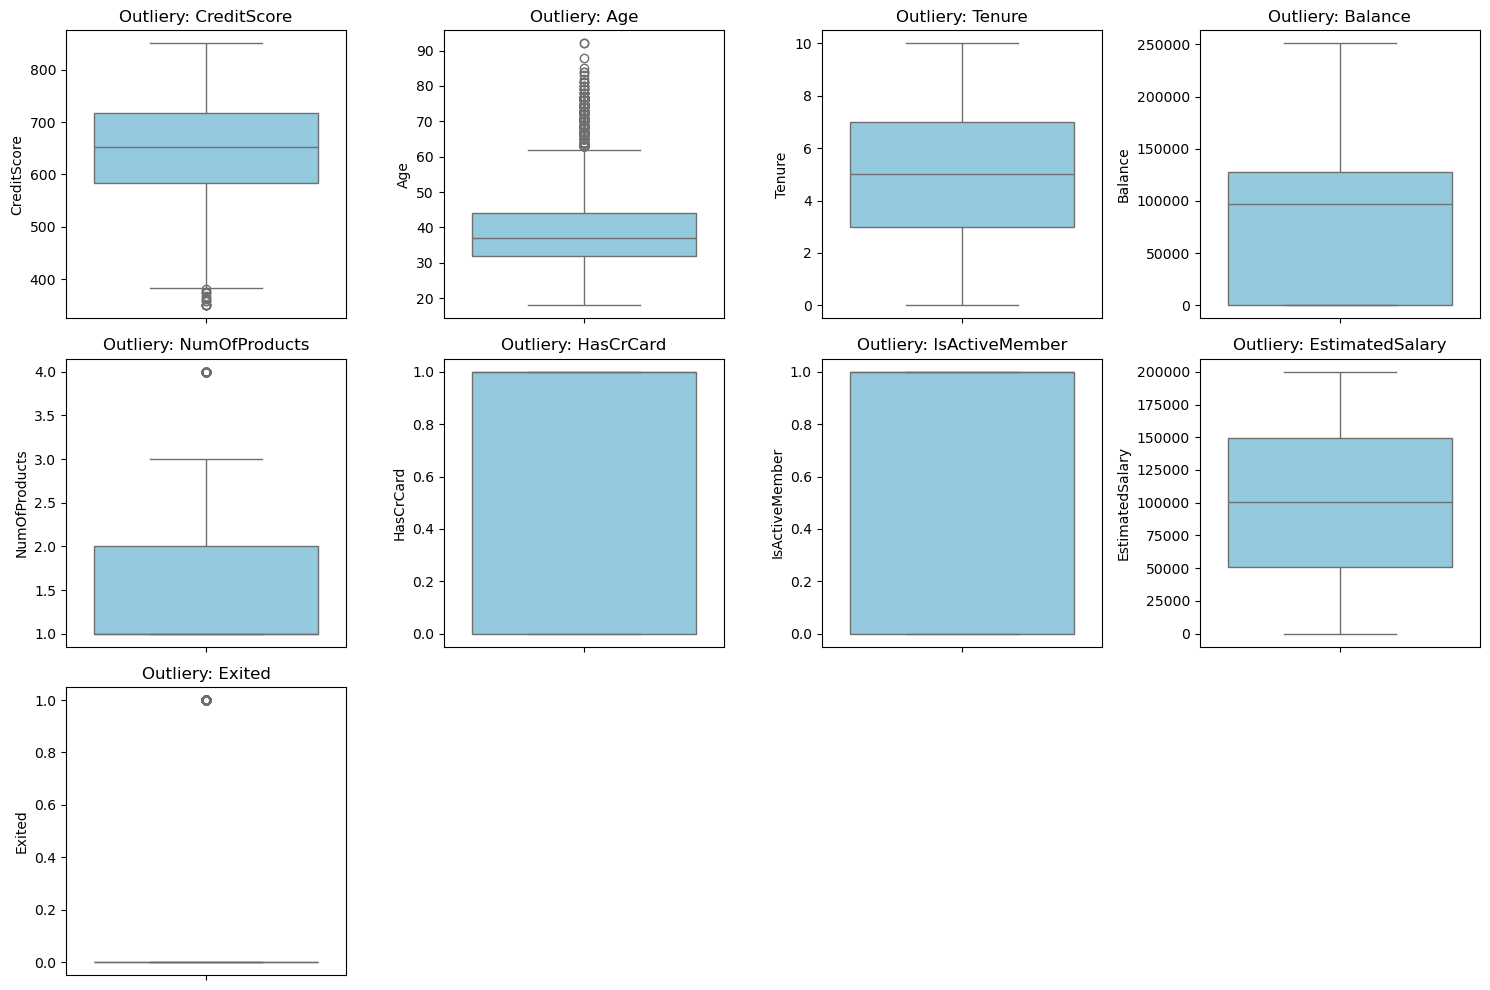

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Tworzymy siatkę wykresów
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i + 1) 
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliery: {col}')
    plt.tight_layout()

plt.show()

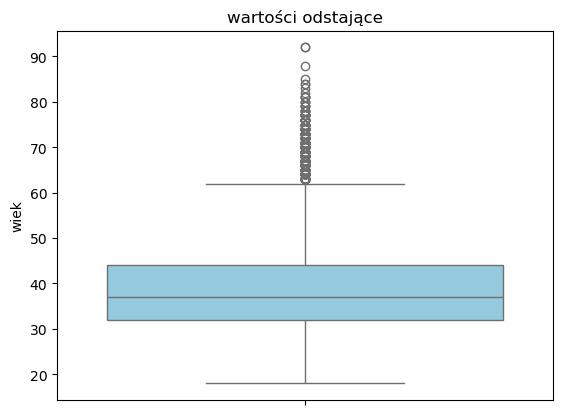

In [ ]:
# W tym wypadku nie będziemy usuwać outlierów, ze względu na to że nie jest to błąd pomiaru 

plt.Figure(figsize=(8,6))

sns.boxplot(y=df['Age'], color='skyblue')
plt.title('wartości odstające')
plt.ylabel('wiek')
plt.show()

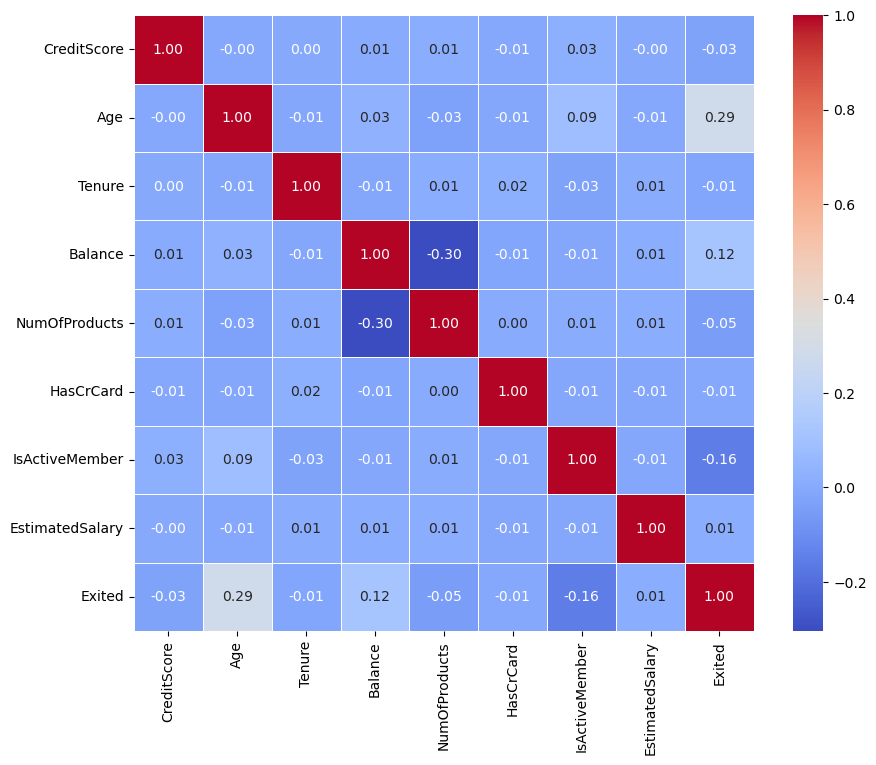

In [ ]:
#Sprawdzamy korelacje naszych danych


num_corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    num_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5)

plt.show()

In [23]:
# sprawadzamy jak z balansowane są klasy 

df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [26]:
target = 'Exited'

X = df.drop(columns= 'Exited')
y = df[target]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#dzielimy dane na dane numeryczne i kategoryczne

num_cols_m = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols_m = X.select_dtypes(include=['object', 'string']).columns

In [58]:
num_proccesor = SkPipeline([
    ('impuer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [59]:
cat_proccesor = SkPipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder())
])

In [60]:
# łączymy dane za pomocą columns transformera 

preprocces = ColumnTransformer([
    ('num_procesor', num_proccesor, num_cols_m),
    ('cat_procesor', cat_proccesor, cat_cols_m)
])

In [61]:
# inicjujemy nasz model 

model_xgb = XGBClassifier(n_estimators = 100 , random_state = 42)

In [62]:
#  łączymy całość w Pipeline

pipeline = SkPipeline([
    ('procesowanie', preprocces),
    ('model_xgb', model_xgb)
])

In [63]:
# trenujemy model 

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [68]:
cm = confusion_matrix(y_test, y_pred)
print("Raport klasyfikacji :")
print(classification_report(y_test, y_pred))
print("Macierz pomyłek:")
print(cm)

Raport klasyfikacji :
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1607
           1       0.69      0.50      0.58       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Macierz pomyłek:
[[1521   86]
 [ 198  195]]


Jak możemy zauważyć model ma problem z 'wyłapniem' osób odchodzących ze względu na niezbalansowane dane, dlatego użyjemy metody Smote.

In [74]:
pipeline_borderline = ImbPipeline([
    ('preprocessor', preprocces),
    ('smote', BorderlineSMOTE(random_state=42)),
    ('model', model_xgb)
])

In [75]:
pipeline_borderline.fit(X_train, y_train)
y_pred_border = pipeline_borderline.predict(X_test)

In [76]:
cmb = confusion_matrix(y_test, y_pred_border)

print("Raport klasyfikacji (Borderline-SMOTE):")
print(classification_report(y_test, y_pred_border))
print("Macierz pomyłek:")
print(cmb)

Raport klasyfikacji (Borderline-SMOTE):
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1607
           1       0.62      0.58      0.60       393

    accuracy                           0.85      2000
   macro avg       0.76      0.75      0.75      2000
weighted avg       0.84      0.85      0.84      2000

Macierz pomyłek:
[[1464  143]
 [ 164  229]]


In [ ]:
def objective(trial):
    
    param = {
        'smote__sampling_strategy': trial.suggest_float('smote__sampling_strategy', 0.5, 1.0),
        'model__max_depth': trial.suggest_int('model__max_depth', 3, 10),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.3, log=True),
        'model__n_estimators': trial.suggest_int('model__n_estimators', 100, 500),
        'model__subsample': trial.suggest_float('model__subsample', 0.5, 1.0),
    }

    
    pipeline_borderline.set_params(**param)

    #Sprawdzamy model (Scoring dajemy na recall żeby skupić sie osobach które odchodzą)
    
    score = cross_val_score(pipeline_borderline, X_train, y_train, cv=3, scoring='recall').mean()
    
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) 

print("Najlepszy wynik Recall:", study.best_value)
print("Najlepsze parametry:", study.best_params)

In [ ]:
# Ustawiamy najlepsze znalezione  parametry 

pipeline_borderline.set_params(**study.best_params)
pipeline_borderline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_procesor', ...), ('cat_procesor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready f

In [ ]:
y_pred_standard = pipeline_borderline.predict(X_test)


print("Raport klasyfikacji :")
print(classification_report(y_test, y_pred_standard))

print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_standard))

Raport klasyfikacji :
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1607
           1       0.48      0.77      0.59       393

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000

Macierz pomyłek:
[[1285  322]
 [  92  301]]


Dzięki zastosowaniu optymalizacji hiperparametrów udało się podnieść czułość modelu (Recall) z 0.58 do 0.77 przy zachowaniu akceptowalnego poziomu precyzji. Oznacza to, że model skutecznie identyfikuje ponad 3/4 klientów zagrożonych odejściem, co czyni go wartościowym narzędziem w strategii na zatrzymanie klienta w  banku.

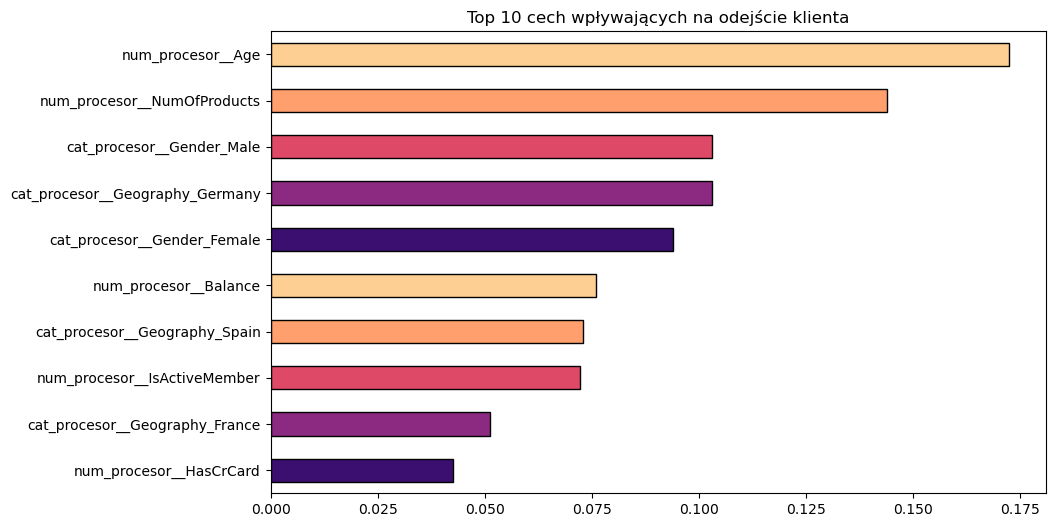

In [ ]:
importances = pipeline_borderline.named_steps['model'].feature_importances_
features = pipeline_borderline.named_steps['preprocessor'].get_feature_names_out()

# tworzymy  wykres  przedtawiający 10 najważniejszych cech dla modelu
plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values().tail(10).plot(
    kind='barh',
    color=plt.cm.magma([0.2, 0.4, 0.6, 0.8, 0.9]),
    edgecolor = 'black')
plt.title("Top 10 cech wpływających na odejście klienta")
lt.savefig('../images/top_10_model.png', dpi=300, bbox_inches='tight')
plt.show()